https://www.kaggle.com/datasets/faisalsanto007/isear-dataset  
https://www.kaggle.com/datasets/debarshichanda/goemotions  
https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Go emotions

In [2]:
df1 = pd.read_csv("../data/project/goemotions_1.csv")
df2 = pd.read_csv("../data/project/goemotions_2.csv")
df3 = pd.read_csv("../data/project/goemotions_3.csv")

goemotions = pd.concat([df1, df2, df3], ignore_index=True)



print(goemotions.shape)
goemotions.head()

(211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [3]:
emotion_cols = goemotions.columns[9:]  # od 'admiration' do 'neutral'

goemotions_clean = goemotions[["text"] + list(emotion_cols)].copy()

# usuwamy wiersze bez żadnej emocji
goemotions_clean["sum_emotions"] = goemotions_clean[emotion_cols].sum(axis=1)
goemotions_clean = goemotions_clean[goemotions_clean["sum_emotions"] > 0]

goemotions_clean.drop(columns=["sum_emotions"], inplace=True)

goemotions_clean.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,"You do right, if you don't care then fuck 'em!",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,Right? Considering it’s such an important docu...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
emotion_distribution = goemotions_clean[emotion_cols].sum().sort_values(ascending=False)

print(emotion_distribution)

neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
sadness            6758
caring             5999
excitement         5629
surprise           5514
disgust            5301
desire             3817
fear               3197
remorse            2525
embarrassment      2476
nervousness        1810
pride              1302
relief             1289
grief               673
dtype: int64


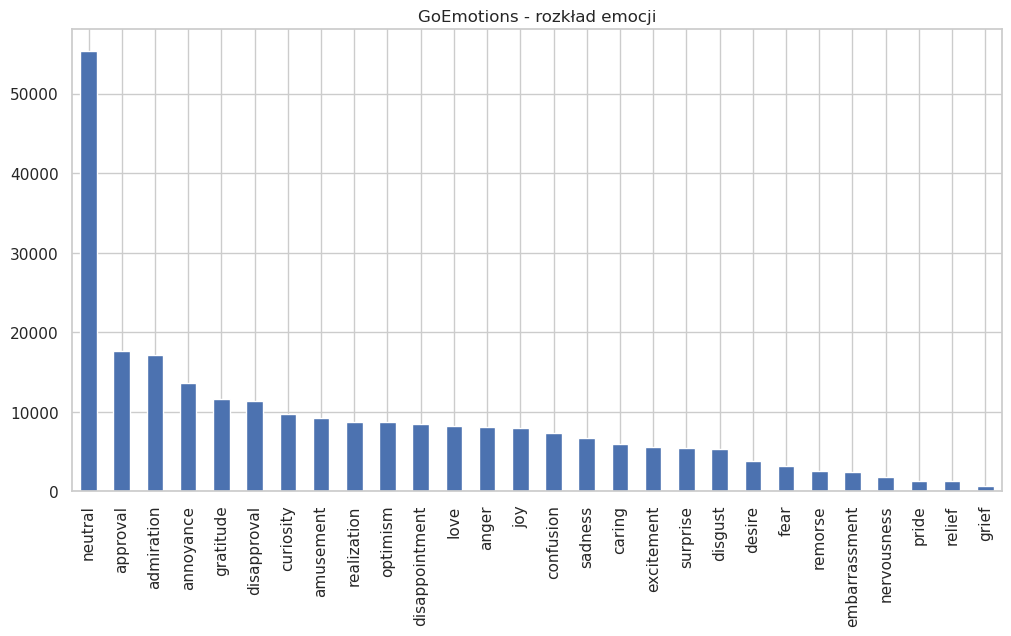

In [5]:
plt.figure()
emotion_distribution.plot(kind="bar")
plt.title("GoEmotions - rozkład emocji")
plt.xticks(rotation=90)
plt.show()

# Combine emotions

In [6]:
combined = pd.read_csv("../data/project/combined_emotion.csv")

combined["emotion"] = combined["emotion"].replace({"sad": "sadness"})
combined["emotion"] = combined["emotion"].replace({"suprise": "surprise"})

print(combined.shape)
combined.head()

(422746, 2)


,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sadness
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sadness
4,i am a kindergarten teacher and i am thoroughl...,fear


In [7]:
combined_clean = combined[["sentence", "emotion"]].dropna().copy()

combined_clean.head()

,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sadness
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sadness
4,i am a kindergarten teacher and i am thoroughl...,fear


In [8]:
combined_stats = combined_clean["emotion"].value_counts()

print(combined_stats)

emotion
joy         143067
sadness     121187
anger        59317
fear         49649
love         34554
surprise     14972
Name: count, dtype: int64


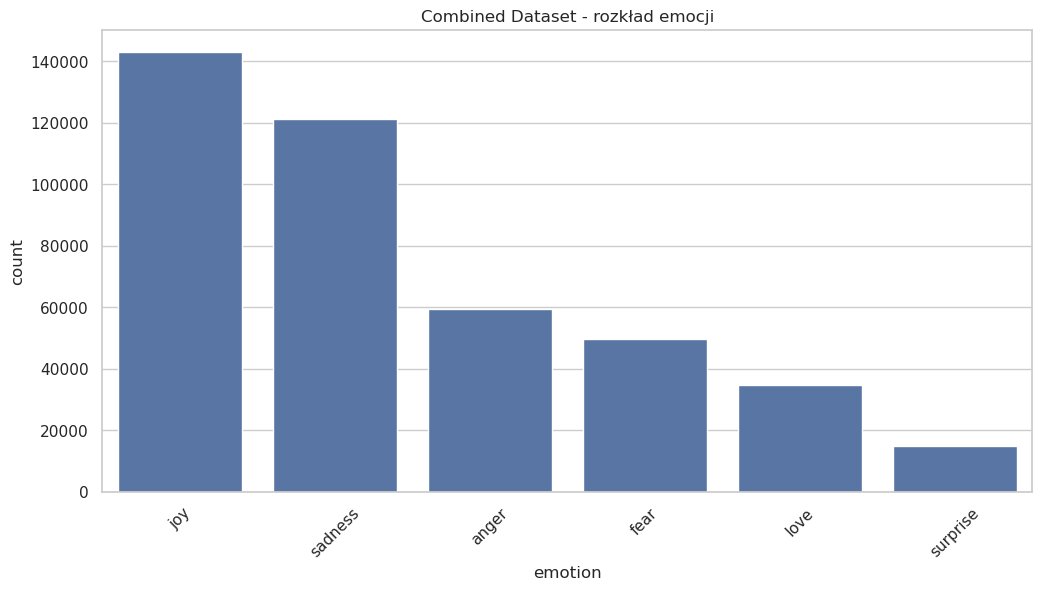

In [9]:
plt.figure()
sns.countplot(data=combined_clean, x="emotion", order=combined_stats.index)
plt.title("Combined Dataset - rozkład emocji")
plt.xticks(rotation=45)
plt.show()

# ISEAR

In [10]:
isear = pd.read_csv("../data/project/ISEAR_dataset_complete.csv")

print(isear.shape)
isear.head()

(7516, 3)


,emotion,content,Unnamed: 2
0,joy,On days when I feel close to my partner and ot...,NaN
1,fear,Every time I imagine that someone I love or I ...,NaN
2,anger,When I had been obviously unjustly treated and...,NaN
3,sadness,When I think about the short time that we live...,NaN
4,disgust,At a gathering I found myself involuntarily si...,NaN


In [11]:
isear_clean = isear[["content", "emotion"]].dropna().copy()

isear_clean.head()

,content,emotion
0,On days when I feel close to my partner and ot...,joy
1,Every time I imagine that someone I love or I ...,fear
2,When I had been obviously unjustly treated and...,anger
3,When I think about the short time that we live...,sadness
4,At a gathering I found myself involuntarily si...,disgust


In [12]:
isear_stats = isear_clean["emotion"].value_counts()

print(isear_stats)

emotion
joy        1092
sadness    1082
anger      1079
fear       1076
shame      1071
disgust    1066
guilt      1050
Name: count, dtype: int64


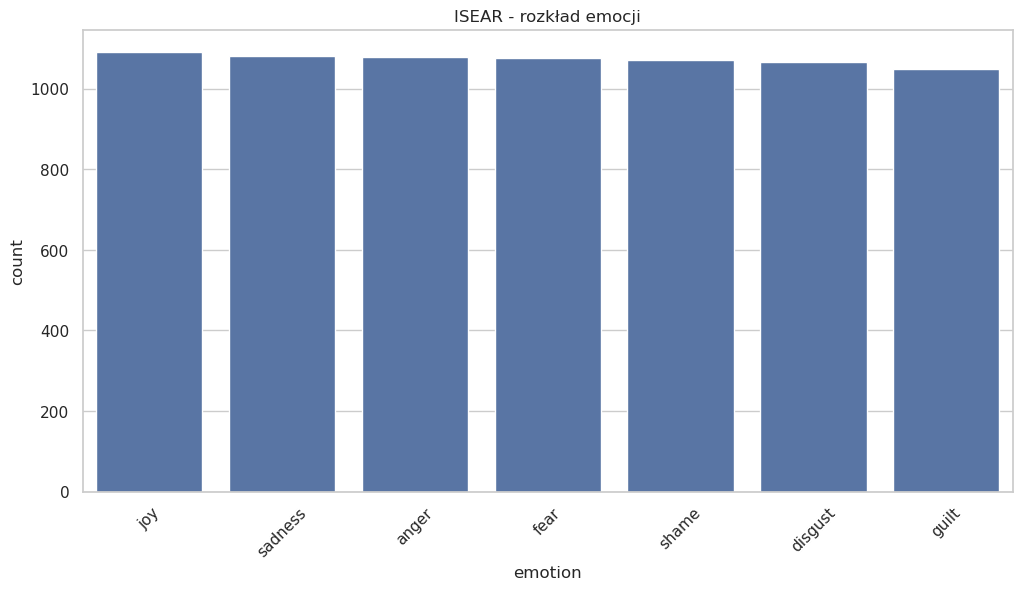

In [13]:
plt.figure()
sns.countplot(data=isear_clean, x="emotion", order=isear_stats.index)
plt.title("ISEAR - rozkład emocji")
plt.xticks(rotation=45)
plt.show()

# razem

In [14]:
goemotions_clean["length"] = goemotions_clean["text"].apply(len)
combined_clean["length"] = combined_clean["sentence"].apply(len)
isear_clean["length"] = isear_clean["content"].apply(len)

print("GoEmotions avg length:", goemotions_clean["length"].mean())
print("Combined avg length:", combined_clean["length"].mean())
print("ISEAR avg length:", isear_clean["length"].mean())

GoEmotions avg length: 69.41395189929456
Combined avg length: 97.03398021507005
ISEAR avg length: 116.78485896753592


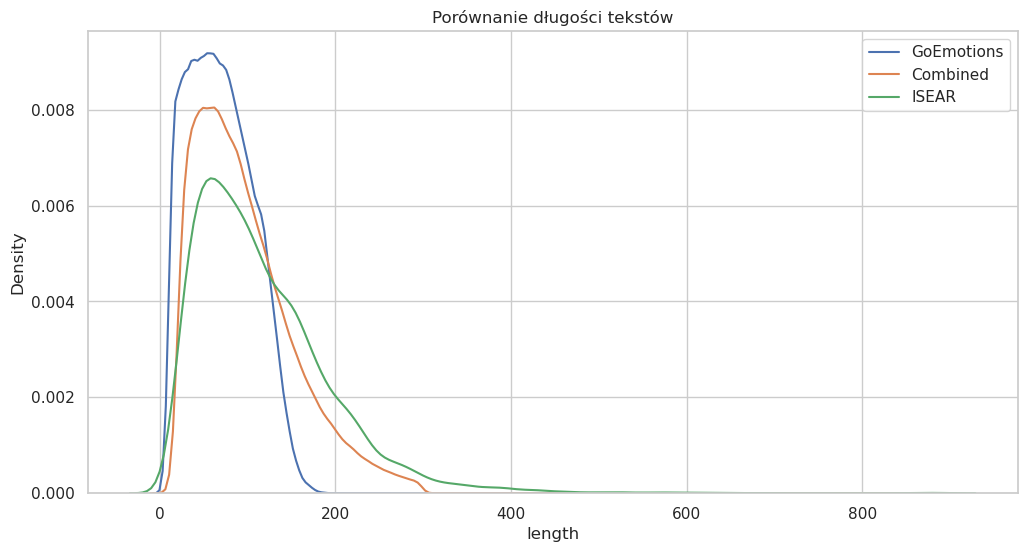

In [15]:
plt.figure()

sns.kdeplot(goemotions_clean["length"], label="GoEmotions")
sns.kdeplot(combined_clean["length"], label="Combined")
sns.kdeplot(isear_clean["length"], label="ISEAR")

plt.legend()
plt.title("Porównanie długości tekstów")
plt.show()

In [16]:
comparison = pd.DataFrame({
    "dataset": ["GoEmotions", "Combined", "ISEAR"],
    "num_classes": [
        len(emotion_cols),
        combined_clean["emotion"].nunique(),
        isear_clean["emotion"].nunique()
    ],
    "num_samples": [
        len(goemotions_clean),
        len(combined_clean),
        len(isear_clean)
    ]
})

comparison

,dataset,num_classes,num_samples
0,GoEmotions,28,207814
1,Combined,6,422746
2,ISEAR,7,7516


In [17]:
goemotions_clean.to_csv("../data/project/goemotions_clean.csv", index=False)
combined_clean.to_csv("../data/project/combined_clean.csv", index=False)
isear_clean.to_csv("../data/project/isear_clean.csv", index=False)

# jakie dataset jakie emocje

In [95]:
# GoEmotions (kolumny emocji)
go_classes = list(emotion_cols)

# Combined
combined_classes = combined_clean["emotion"].unique().tolist()

# ISEAR
isear_classes = isear_clean["emotion"].unique().tolist()

all_classes = sorted(set(go_classes + combined_classes + isear_classes))

print("Liczba wszystkich unikalnych klas:", len(all_classes))

Liczba wszystkich unikalnych klas: 30


In [96]:
presence = pd.DataFrame(index=all_classes)

presence["GoEmotions"] = [1 if c in go_classes else 0 for c in all_classes]
presence["Combined"] = [1 if c in combined_classes else 0 for c in all_classes]
presence["ISEAR"] = [1 if c in isear_classes else 0 for c in all_classes]

presence.head(20)

,GoEmotions,Combined,ISEAR
admiration,1,0,0
amusement,1,0,0
anger,1,1,1
annoyance,1,0,0
approval,1,0,0
caring,1,0,0
confusion,1,0,0
curiosity,1,0,0
desire,1,0,0
disappointment,1,0,0


In [97]:
# emocje obecne we wszystkich 3 datasetach
common_mask = (presence["GoEmotions"] == 1) & \
              (presence["Combined"] == 1) & \
              (presence["ISEAR"] == 1)

# maska: True tylko tam gdzie emocja jest w 3 datasetach
common_cells = presence.eq(1) & presence.all(axis=1).values[:, None]

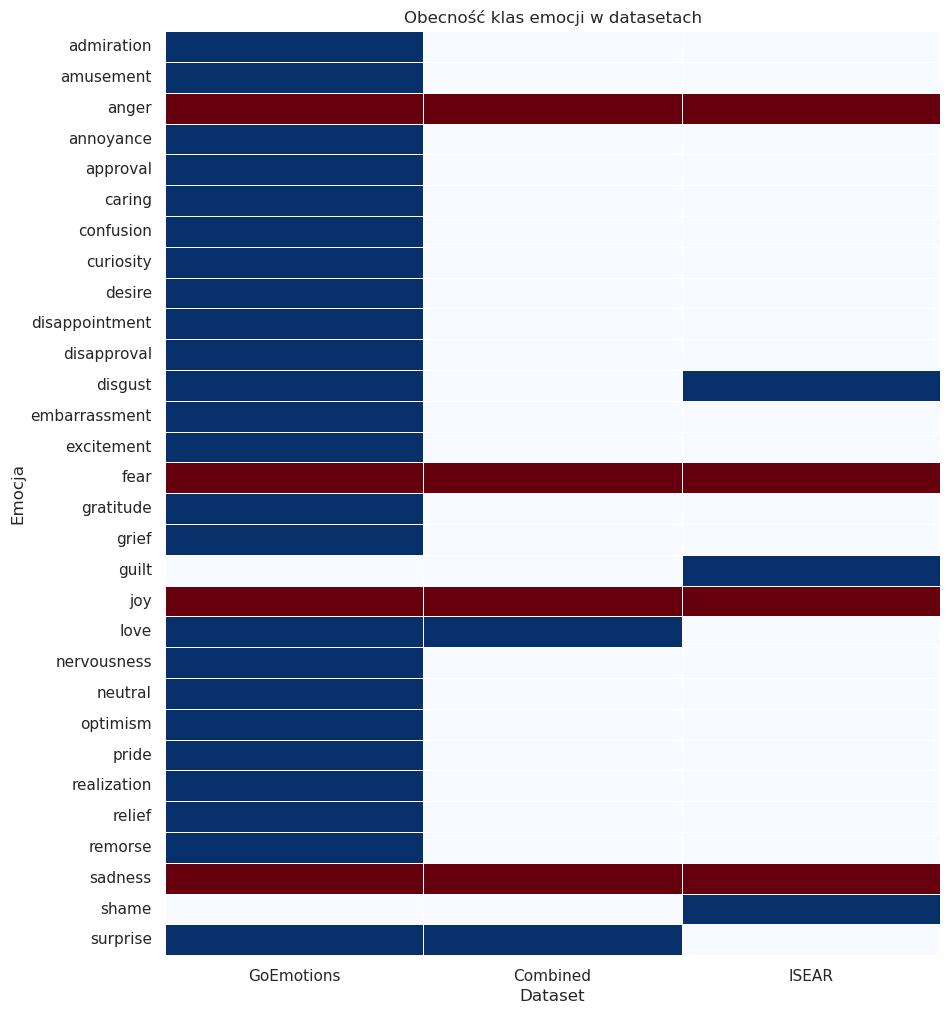

In [98]:
plt.figure(figsize=(10, 12))

# bazowa heatmapa (niebieska)
sns.heatmap(presence, cmap="Blues", cbar=False, linewidths=0.5)

# NAŁOŻENIE czerwonego koloru tylko na wspólne emocje
sns.heatmap(
    presence,
    cmap="Reds",
    vmin=0, vmax=1,   # <-- KLUCZOWE
    cbar=False,
    linewidths=0.5,
    mask=~common_cells, 
)

plt.title("Obecność klas emocji w datasetach")
plt.xlabel("Dataset")
plt.ylabel("Emocja")

plt.show()

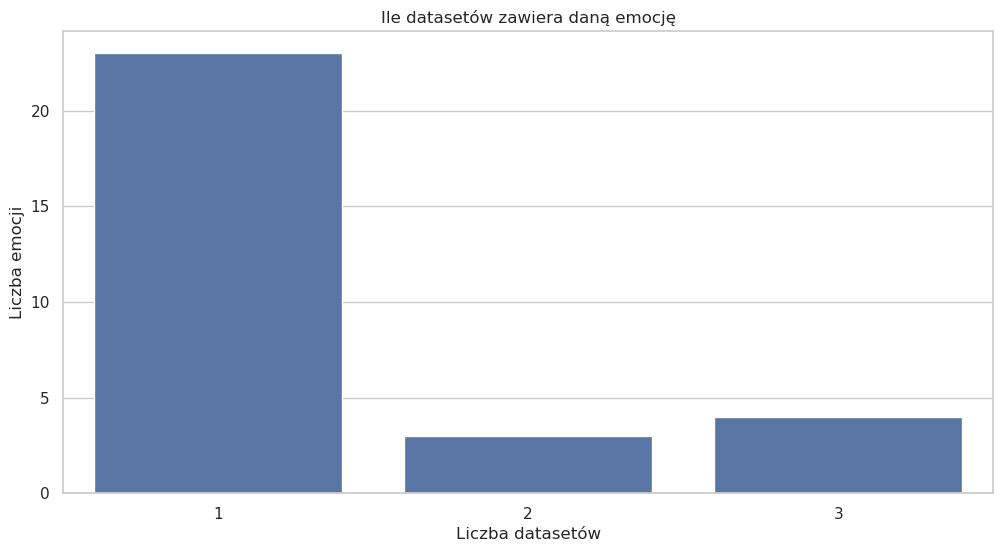

In [99]:
presence["count_datasets"] = presence.sum(axis=1)

plt.figure()

sns.countplot(x="count_datasets", data=presence)

plt.title("Ile datasetów zawiera daną emocję")
plt.xlabel("Liczba datasetów")
plt.ylabel("Liczba emocji")

plt.show()

In [100]:
only_one = presence[presence["count_datasets"] == 1].index.tolist()
in_two = presence[presence["count_datasets"] == 2].index.tolist()
in_all = presence[presence["count_datasets"] == 3].index.tolist()

print("Tylko w jednym datasetcie:", only_one)
print("\nW dwóch datasetach:", in_two)
print("\nWe wszystkich:", in_all)

Tylko w jednym datasetcie: ['admiration', 'amusement', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'embarrassment', 'excitement', 'gratitude', 'grief', 'guilt', 'nervousness', 'neutral', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'shame']

W dwóch datasetach: ['disgust', 'love', 'surprise']

We wszystkich: ['anger', 'fear', 'joy', 'sadness']


In [101]:
mapping = {
    "happiness": "joy",
    "sad": "sadness",
    "fearful": "fear",
    "angry": "anger"
}

In [66]:
combined_clean["emotion_norm"] = combined_clean["emotion"].replace(mapping)
isear_clean["emotion_norm"] = isear_clean["emotion"].replace(mapping)